# Melbourne Street Network Analysis

Collect street network data and analyse it ready for use in modelling

In [3]:
import requests  # for downloading data
import os

import pandas as pd
import geopandas as gpd
import contextily as cx
import osmnx as ox

from zipfile import ZipFile

## Load data

~First some other data so that we know the spatial extent of the area that we are using.  Use the landmarks data from the [Melbourne Open Data Portal](https://data.melbourne.vic.gov.au/People/Landmarks-and-places-of-interest-including-schools/j5vt-ppat)~

_This was unnecessary because the road network data we download are already clipped to the area of interest_

### Melbourne pedestrian network

Now get the road network data. Use the [pedestrian route data](https://data.melbourne.vic.gov.au/Transport/Pedestrian-Network/4id4-tydi) that are already available. These are shared as a `zip` file so download and extract that first if needed.

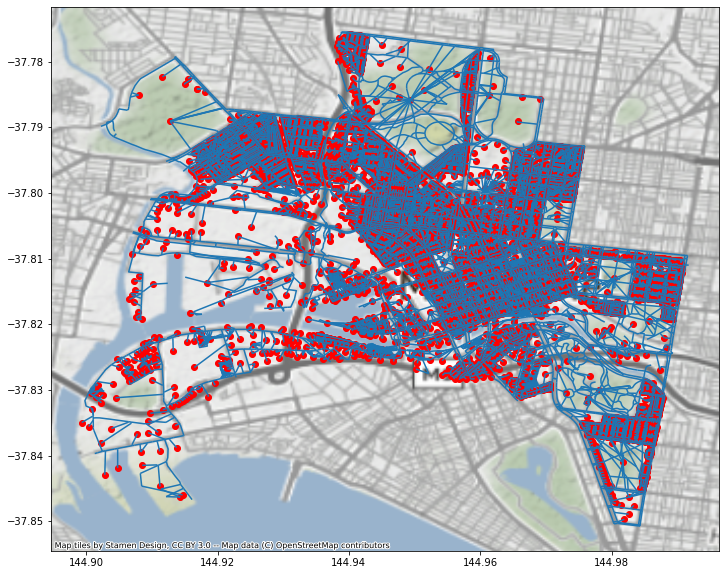

In [12]:
network_file = "Pedestrian_network.json"
property_file = "Property_centroid.json"

if not os.path.exists(network_file):
    zip_filename = "Pedestrian_Network.zip"
    print("Street network data doesn't exist, downloading ...",)
    url = "https://data.melbourne.vic.gov.au/download/4id4-tydi/application%2Fzip"
    response = requests.get(url)
    with open(zip_filename, 'wb') as f:
        f.write(response.content) 
    print("\t ... finished. Extracting zipfile ...",)
    with ZipFile(zip_filename, 'r') as zObject:
        zObject.extractall()
    # Should have two new files
    assert os.path.exists(network_file)
    assert os.path.exists(property_file)
    os.remove(zip_filename)
    
network = gpd.read_file(network_file, crs="EPSG:4326")
properties = gpd.read_file(property_file, crs="EPSG:4326")
ax = network.plot(figsize=(12,10))
properties.plot(ax=ax, color='red')
cx.add_basemap(ax, crs=network.crs, zoom=12)

### Melbourne Boundary

Get the [municipal boundary](https://data.melbourne.vic.gov.au/Property/Municipal-boundary/ck33-yh8z) (i.e. the study area)

In [ ]:
boundary_file = "Municipal-boundary.shp"

if not os.path.exists(boundary_file):
    print("Boundary data doesn't exist, downloading ...",)
    url = "https://data.melbourne.vic.gov.au/api/geospatial/ck33-yh8z?method=export&format=Shapefile"
    response = requests.get(url)
    with open(boundary_file, 'wb') as f:
        f.write(response.content) 
    print("\t ... finished")

boundary = gpd.read_file(boundary_file)
boundary.plot()

## Calculate space syntax statistics

In [ ]:
ox.plot_graph(ox.graph_from_place('Melbourne, Australia'))

In [ ]:
G = ox.graph_from_polygon(boundary, network_type='pedestrian')
ox.plot_graph(G)